# 1. Imports #

In [17]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

#Sklearn bibliotheken
from sklearn import datasets
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline #niet heel belangrijk, zet samen standard scaler en linear svc
from sklearn.preprocessing import StandardScaler #standardisatie: gem 0, std 1 
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# 2. Data #

## 2.1 Load ##

In [18]:
iris = datasets.load_iris()
df = pd.DataFrame(iris["data"],columns=iris["feature_names"])
df.head(150)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 2.2 Visualize ##

### 2.2.1 Histogrammen ###

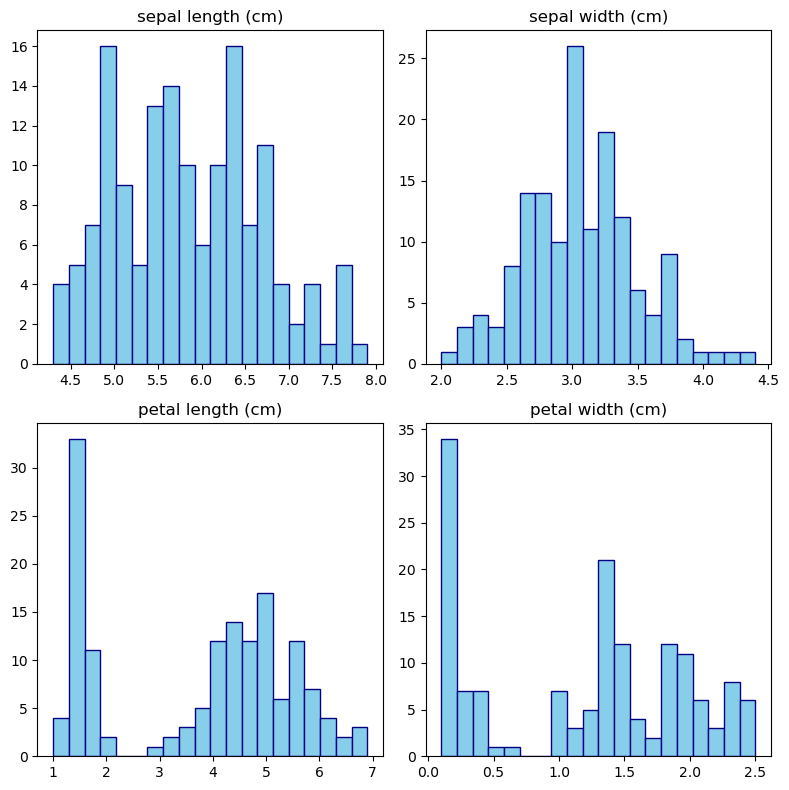

In [24]:
plt.figure(figsize=(8, 8)) #maakt nieuwe figuur waarin alle grafiek komen 8 inch breed 8 inch hoog (vierkante afbeelding)

for i in range(4):         #dwz herhaalt de code 4 keer, i wordt achtereenvolgens: 0,1,2,3 omdat de Iris data 4 kolommen (features) heeft 
    plt.subplot(2, 2, i+1)   #plt.subplot(rijen,kolommen,positie) hier 2 rijen, 2 kolommen, positie=i+1
    plt.hist(X[:, i], bins=20, color='skyblue', edgecolor='navy')
    plt.title(feature_names[i])

plt.tight_layout()
plt.show()

### 2.2.2 Gaussische verdeling (sepal width) ###

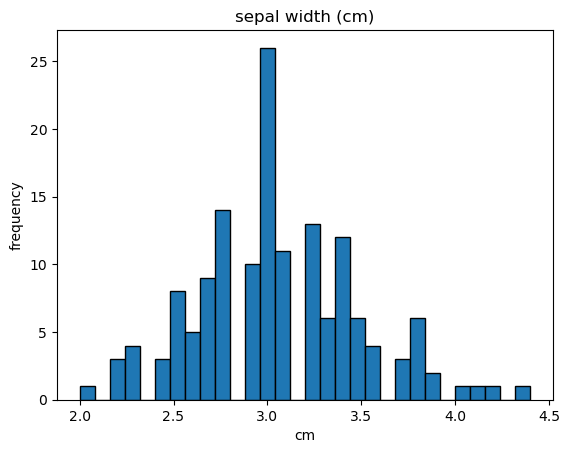

In [23]:
plt.hist(X[:,1],bins=30, edgecolor='black')
plt.xlabel('cm')
plt.ylabel('frequency')
plt.title(feature_names[1])
plt.show()

## 2.3 Standiseren en outliers (nuniet) ##

## 2.4 Train/test split ##

In [27]:
X = iris["data"][:, 3:] # petal width
y = (iris["target"] == 2).astype(int) # 1 if Iris-Virginica, else 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(120, 30, 120, 30)

# 3. Hyperparameters tuning (dit puntje als laatste) #

## 3.1 Parameter range kiezen ##

## 3.2 Cross-Fold validation (CV) ##

## 3.3 Best parameters ## 

# 4. Training (nemen van training set) #

## 4.1 fixed hyperparameters ##

### 4.1.1 SVM classification ###

In [35]:
svm_clf = Pipeline([("scaler", StandardScaler()),
("linear_svc", LinearSVC(C=1, loss="hinge")),])

### 4.1.2 SVM regression ###

In [38]:
SVMX = SVR(kernel='rbf', gamma='scale',
         C=1.0,         # Regularization parameter
         epsilon= 0.1   # Epsilon-parameter: tube width
         )

## 4.2 model.fit(X_train, y_train) inputs als outputs meegeven ##

In [43]:
svm_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [44]:
SVMX.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## 4.3 r2;RMSE, MAE (regressie) ##

## 4.3 accuracy, confusion matrix (classificatie) zoek dit vooral op want er zijn ingebouwde functies hiervoor ##

# 5. Test #

## 5.1 model.predict(X_test) ##

In [47]:
predicted=svm_clf.predict(X_test)
print(y_test) 


[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0]


In [50]:
predicted=SVMX.predict(X_test)
print(predicted)
print(y_test)

[-0.08601578  0.09548796  1.03237623  0.26853661  0.10030654  0.09990768
 -0.0204001   1.03237623  0.26853661 -0.08601578  1.07140041  0.09993632
  0.09379556  0.09993632  0.09548796  0.46621331  1.08206101 -0.10020204
 -0.0204001   1.08206101  0.09379556  0.84928156  0.09990768  1.09998569
  1.07140041  1.03237623  0.84928156  1.03237623  0.09548796  0.09379556]
[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0]


## 5.2 r2, RMSE,MAE ##

## 5.3 accuracy, confusion matrix ## 

In [48]:
test_accuracy=svm_clf.score(X_test,y_test) #overeenkomen van X-test en y_test
print(test_accuracy)

1.0


In [51]:
test_accuracy=SVMX.score(X_test,y_test)
print(test_accuracy)

0.9175673571242214
